In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/cmu/idl/final_project/idl_project2/dcnn_variant/final
!ls

Mounted at /content/drive
/content/drive/MyDrive/cmu/idl/final_project/idl_project2/dcnn_variant/final
dcnn_model_FD001.pth  dcnn_model_FD003.pth  explanation.md	      fixes.md
dcnn_model_FD002.pth  dcnn_model_FD004.pth  final_dcnn_variant.ipynb  README.md


<h2>preprocessing.py</h2>


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 1. Configuration & Paper Parameters
# ==========================================
data_dir = '../../6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/'

# The paper selects 14 specific sensors out of the 21 available.
selected_sensors = [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]
sensor_cols = [f's{i}' for i in selected_sensors]

MAX_RUL = 125 # R_early threshold

# Standard C-MAPSS column headers
operational_settings = ['setting1', 'setting2', 'setting3']
all_sensors = [f's{i}' for i in range(1, 22)]
columns = ['id', 'cycle'] + operational_settings + all_sensors

# ==========================================
# 2. Helper Functions
# ==========================================
def add_piecewise_rul(df, max_rul):
    """Calculates the RUL and clips it to the R_early threshold."""
    # Get the max cycle for each engine id
    rul = pd.DataFrame(df.groupby('id')['cycle'].max()).reset_index()
    rul.columns = ['id', 'max_cycle']

    # Merge back and calculate standard RUL
    df = df.merge(rul, on=['id'], how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop('max_cycle', axis=1, inplace=True)

    # Apply Piecewise linear degradation model
    df['RUL'] = df['RUL'].apply(lambda x: min(x, max_rul))
    return df

def generate_sequences(engine_df, seq_length, seq_cols):
    """Generates rolling time windows of shape (N_tw, N_ft)."""
    data_array = engine_df[seq_cols].values
    num_elements = data_array.shape[0]
    # Yield sequences of length seq_length
    for start, stop in zip(range(0, num_elements - seq_length + 1), range(seq_length, num_elements + 1)):
        yield data_array[start:stop, :]

def generate_labels(engine_df, seq_length, label_col):
    """Generates the corresponding RUL label for the last cycle of each window."""
    label_array = engine_df[label_col].values
    num_elements = label_array.shape[0]
    return label_array[seq_length - 1:num_elements]

# ==========================================
# 3. Main Preprocessing Pipeline
# ==========================================
def process_cmapss_data(train_path, test_path, rul_path, sequence_length):
    # Load raw data
    train_df = pd.read_csv(train_path, sep=" ", header=None).drop([26, 27], axis=1)
    test_df = pd.read_csv(test_path, sep=" ", header=None).drop([26, 27], axis=1)
    truth_df = pd.read_csv(rul_path, sep=" ", header=None).drop([1], axis=1)

    train_df.columns = columns
    test_df.columns = columns
    truth_df.columns = ['RUL']

    # 1. Add Piecewise RUL to Training Data
    train_df = add_piecewise_rul(train_df, MAX_RUL)

    # 2. Min-Max Normalization [-1, 1]
    # Fit scaler ONLY on the training data to prevent data leakage
    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
    test_df[sensor_cols] = scaler.transform(test_df[sensor_cols])

    # 3. Generate Training Sequences and Labels
    seq_gen = (list(generate_sequences(train_df[train_df['id'] == engine_id], sequence_length, sensor_cols))
               for engine_id in train_df['id'].unique())
    seq_array = np.concatenate(list(seq_gen)).astype(np.float32)

    label_gen = [generate_labels(train_df[train_df['id'] == engine_id], sequence_length, 'RUL')
                 for engine_id in train_df['id'].unique()]
    label_array = np.concatenate(label_gen).astype(np.float32)

    # 4. Generate Testing Sequences (Using only the last sequence per engine)
    # The paper mentions dropping test engines that are shorter than the window size
    test_seqs = []
    test_labels = []

    for i, engine_id in enumerate(test_df['id'].unique()):
        engine_data = test_df[test_df['id'] == engine_id]
        if len(engine_data) >= sequence_length:
            # Grab the last window of size N_tw
            seq = engine_data[sensor_cols].values[-sequence_length:]
            test_seqs.append(seq)
            # Clip the ground truth test RUL to the piecewise threshold as well
            test_labels.append(min(truth_df.iloc[i]['RUL'], MAX_RUL))

    test_seq_array = np.array(test_seqs).astype(np.float32)
    test_label_array = np.array(test_labels).astype(np.float32)

    return seq_array, label_array, test_seq_array, test_label_array, test_df


# ==========================================
# 4. Execution: Preprocess all datasets
# ==========================================
datasets = ['FD001', 'FD002', 'FD003', 'FD004']
seq_lengths = {'FD001': 30, 'FD002': 20, 'FD003': 30, 'FD004': 15}

processed_data = {}

for dataset_id in datasets:
    seq_length = seq_lengths[dataset_id]
    print(f"\n{'='*40}")
    print(f"Preprocessing {dataset_id} (Window Size: {seq_length})")
    print(f"{'='*40}")

    X_train, y_train, X_test, y_test, test_df = process_cmapss_data(
        f'{data_dir}train_{dataset_id}.txt',
        f'{data_dir}test_{dataset_id}.txt',
        f'{data_dir}RUL_{dataset_id}.txt',
        seq_length
    )

    processed_data[dataset_id] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'test_df': test_df,
        'seq_length': seq_length
    }

    print(f"Train Shape: {X_train.shape}")
    print(f"Test Shape: {X_test.shape}")



Preprocessing FD001 (Window Size: 30)
Train Shape: (17731, 30, 14)
Test Shape: (100, 30, 14)

Preprocessing FD002 (Window Size: 20)
Train Shape: (48819, 20, 14)
Test Shape: (259, 20, 14)

Preprocessing FD003 (Window Size: 30)
Train Shape: (21820, 30, 14)
Test Shape: (100, 30, 14)

Preprocessing FD004 (Window Size: 15)
Train Shape: (57763, 15, 14)
Test Shape: (248, 15, 14)


<h2>model.py</h2>


In [ ]:
import torch
import torch.nn as nn

class PaperDeepCNN(nn.Module):
    def __init__(self, sequence_length=30, num_features=14):
        super(PaperDeepCNN, self).__init__()

        # ==========================================
        # 1. Convolutional Feature Extractors
        # ==========================================
        # Conv Layers 1-4: 10 filters, 10x1 kernel.
        # padding='same' ensures the (30 x 14) dimension remains unchanged.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=(10, 1), padding='same')
        self.conv2 = nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(10, 1), padding='same')
        self.conv3 = nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(10, 1), padding='same')
        self.conv4 = nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(10, 1), padding='same')

        # Conv Layer 5: 1 filter, 3x1 kernel to combine the feature maps
        self.conv5 = nn.Conv2d(in_channels=10, out_channels=1, kernel_size=(3, 1), padding='same')

        # Activation function used throughout the network
        self.tanh = nn.Tanh()

        # ==========================================
        # 2. Regression Tail
        # ==========================================
        self.dropout = nn.Dropout(p=0.5)

        # Flattened size: sequence_length * num_features (30 * 14 = 420)
        flattened_size = sequence_length * num_features

        # From Table 2: 100 neurons in the fully-connected layer
        self.fc1 = nn.Linear(flattened_size, 100)

        # Final output neuron for RUL estimation
        self.fc2 = nn.Linear(100, 1)

        # ==========================================
        # 3. Weight Initialization
        # ==========================================
        # The paper explicitly states Xavier Normal initialization is used
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Input shape expected: (batch_size, sequence_length, num_features)
        # We add a channel dimension to make it compatible with Conv2d:
        # New shape: (batch_size, 1, sequence_length, num_features)
        x = x.unsqueeze(1)

        # Pass through Conv blocks
        x = self.tanh(self.conv1(x))
        x = self.tanh(self.conv2(x))
        x = self.tanh(self.conv3(x))
        x = self.tanh(self.conv4(x))
        x = self.tanh(self.conv5(x))

        # Flatten the 2D feature map to 1D
        x = x.view(x.size(0), -1)

        # Pass through regression tail
        x = self.dropout(x)
        x = self.tanh(self.fc1(x))

        # Final output
        x = self.fc2(x)

        return x

# ==========================================
# 4. Quick Test to Verify Dimensions
# ==========================================
if __name__ == "__main__":
    # Create a dummy batch of 32 samples, 30 cycles, 14 sensors
    dummy_input = torch.randn(32, 30, 14)
    model = PaperDeepCNN()

    # Forward pass
    output = model(dummy_input)

    print(f"Input shape: {dummy_input.shape}")
    print(f"Output shape: {output.shape}") # Expected: (32, 1)

Input shape: torch.Size([32, 30, 14])
Output shape: torch.Size([32, 1])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


<h2>train.py</h2>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import math

# ==========================================
# 1. Custom Metrics & Loss
# ==========================================
class RMSELoss(nn.Module):
    def __init__(self):
        super(RMSELoss, self).__init__()
        self.mse = nn.MSELoss()

    def forward(self, yhat, y):
        # Adding small epsilon to prevent NaN gradients if loss is exactly 0
        return torch.sqrt(self.mse(yhat, y) + 1e-6)

def compute_cmapss_score(y_true, y_pred):
    """
    Computes the asymmetric scoring function defined in the paper.
    Penalizes late predictions (d > 0) more than early predictions (d < 0).
    """
    score = 0.0
    for i in range(len(y_pred)):
        # d_i = Estimated RUL - Actual RUL
        d = y_pred[i] - y_true[i]
        if d < 0:
            score += math.exp(-d / 13.0) - 1
        else:
            score += math.exp(d / 10.0) - 1
    return score

# ==========================================
# 2. Training Loop Setup
# ==========================================
def train_model(X_train, y_train, X_test, y_test, sequence_length, device='cpu'):
    # Convert numpy arrays to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

    # Create DataLoader with a batch size of 512 as specified in the paper
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

    # Initialize model, loss, and optimizer
    model = PaperDeepCNN(sequence_length=sequence_length).to(device)
    criterion = RMSELoss()

    # Base learning rate of 0.001
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # LR Scheduler: Drop LR by a factor of 0.1 (to 0.0001) at epoch 200
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[200], gamma=0.1)

    # ==========================================
    # 3. Execution
    # ==========================================
    epochs = 250
    print("Starting training...")

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            # Forward pass
            predictions = model(batch_X)

            # Compute loss
            loss = criterion(predictions, batch_y)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        # Step the learning rate scheduler
        scheduler.step()

        # Print progress every 25 epochs
        if epoch % 25 == 0 or epoch == 1:
            avg_train_loss = np.mean(batch_losses)
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch [{epoch}/{epochs}] | Train RMSE: {avg_train_loss:.4f} | LR: {current_lr:.6f}")

    # ==========================================
    # 4. Final Evaluation on Test Set
    # ==========================================
    print("\nEvaluating on Test Set...")
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_tensor)

        # Calculate Test RMSE
        test_rmse = criterion(test_predictions, y_test_tensor).item()

        # Calculate Test Score
        y_pred_np = test_predictions.cpu().numpy().flatten()
        y_true_np = y_test_tensor.cpu().numpy().flatten()
        test_score = compute_cmapss_score(y_true_np, y_pred_np)

        print("-" * 30)
        print(f"Final Test RMSE:  {test_rmse:.4f}")
        print(f"Final Test Score: {test_score:.2f}")
        print("-" * 30)

    return model

# ==========================================
# 5. Execution: Train models for all datasets
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trained_models = {}

for dataset_id, data in processed_data.items():
    print(f"\n{'='*40}")
    print(f"Training Deep CNN for {dataset_id}")
    print(f"{'='*40}")

    trained_model = train_model(
        data['X_train'], data['y_train'], data['X_test'], data['y_test'],
        data['seq_length'], device=device
    )
    trained_models[dataset_id] = trained_model
    model_path = f'dcnn_model_{dataset_id}.pth'
    torch.save(trained_model.state_dict(), model_path)
    print(f"Saved model weights to {model_path}")



Training Deep CNN for FD001
Starting training...
Epoch [1/250] | Train RMSE: 82.6084 | LR: 0.001000
Epoch [25/250] | Train RMSE: 23.0061 | LR: 0.001000
Epoch [50/250] | Train RMSE: 12.9854 | LR: 0.001000
Epoch [75/250] | Train RMSE: 11.8321 | LR: 0.001000
Epoch [100/250] | Train RMSE: 11.2275 | LR: 0.001000
Epoch [125/250] | Train RMSE: 10.8704 | LR: 0.001000
Epoch [150/250] | Train RMSE: 10.7225 | LR: 0.001000
Epoch [175/250] | Train RMSE: 10.5721 | LR: 0.001000
Epoch [200/250] | Train RMSE: 10.3891 | LR: 0.000100
Epoch [225/250] | Train RMSE: 10.2078 | LR: 0.000100
Epoch [250/250] | Train RMSE: 10.1960 | LR: 0.000100

Evaluating on Test Set...
------------------------------
Final Test RMSE:  13.1439
Final Test Score: 311.05
------------------------------
Saved model weights to dcnn_model_FD001.pth

Training Deep CNN for FD002
Starting training...
Epoch [1/250] | Train RMSE: 79.6077 | LR: 0.001000
Epoch [25/250] | Train RMSE: 29.7276 | LR: 0.001000
Epoch [50/250] | Train RMSE: 23.431

<h2>evaluate.py</h2>


Evaluating FD001


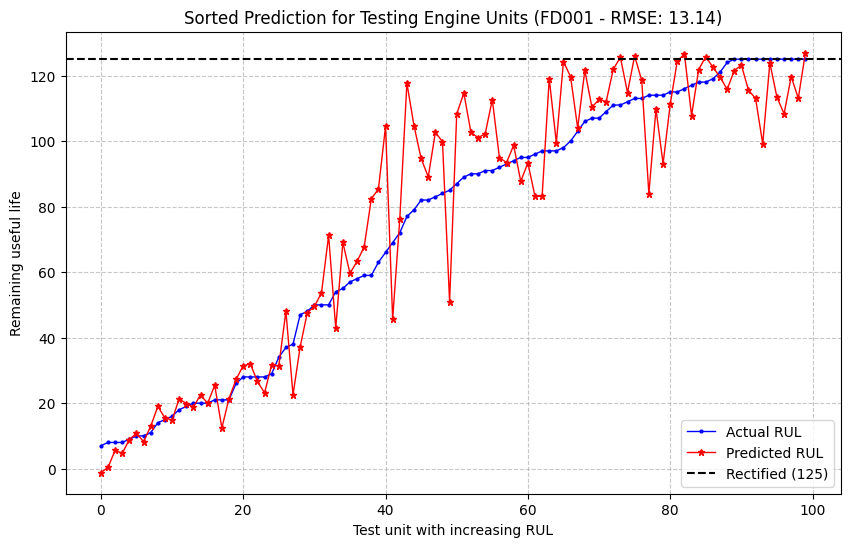


Evaluating FD002


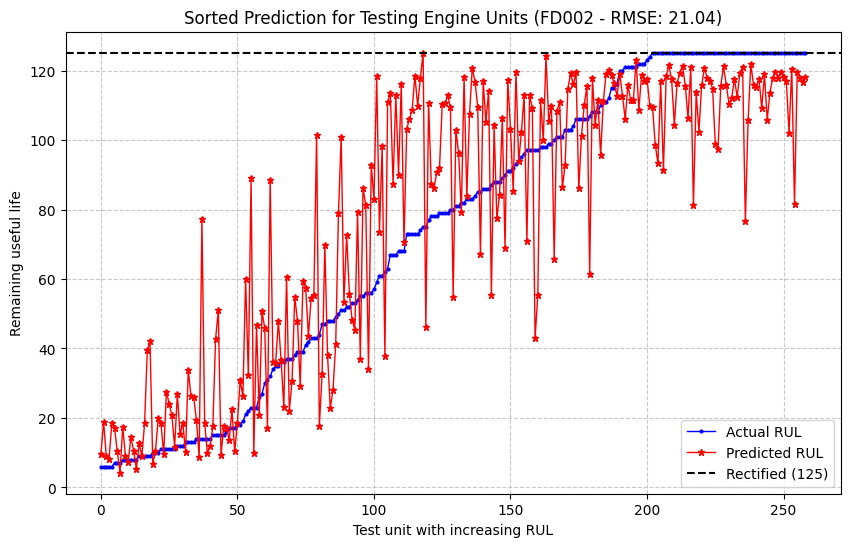


Evaluating FD003


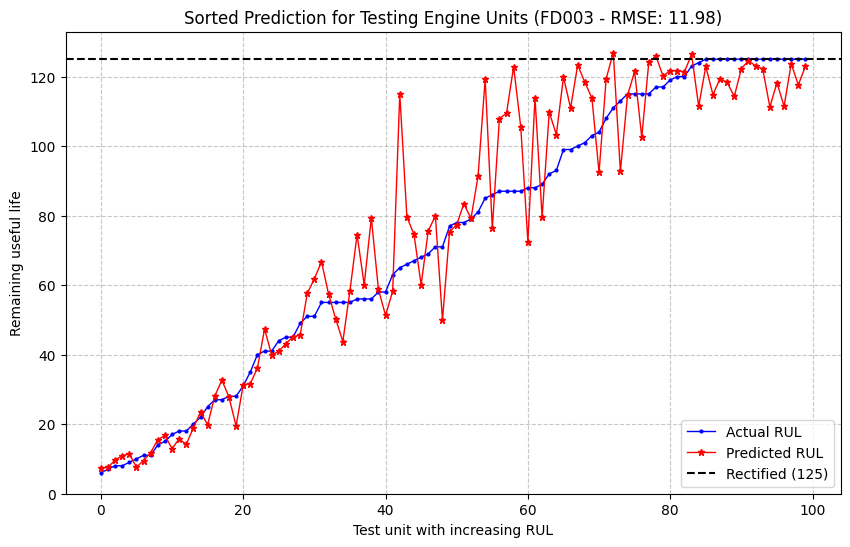


Evaluating FD004


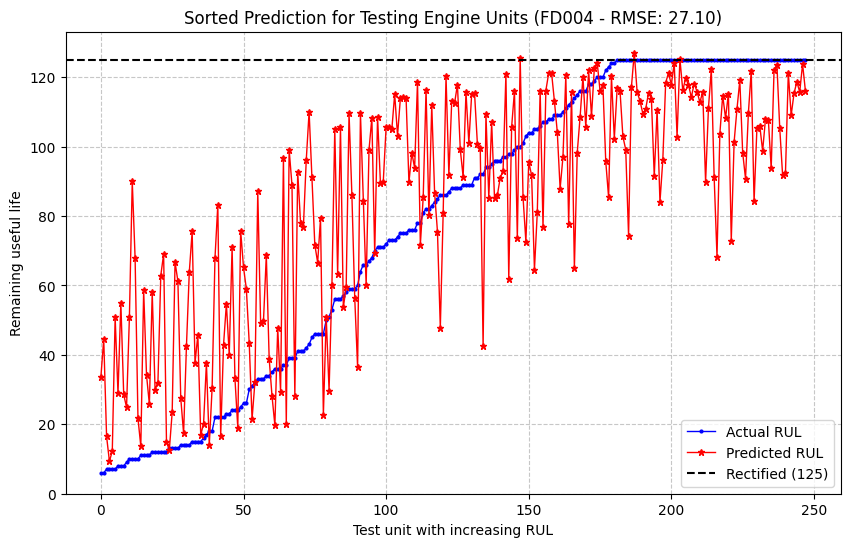

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Replicate Figure 6: Sorted Test Predictions
# ==========================================
def plot_sorted_predictions(model, X_test, y_test, dataset_id, device='cpu'):
    """
    Evaluates the model on the final cycles of the test set,
    sorts the results by the actual RUL, and plots them.
    Replicates Figure 6 from the paper.
    """
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

    with torch.no_grad():
        predictions = model(X_test_tensor).cpu().numpy().flatten()

    actuals = y_test.flatten()

    # Sort indices by actual RUL from smallest to largest
    sorted_indices = np.argsort(actuals)
    sorted_actuals = actuals[sorted_indices]
    sorted_predictions = predictions[sorted_indices]

    plt.figure(figsize=(10, 6))
    plt.plot(sorted_actuals, label='Actual RUL', color='blue', marker='.', markersize=4, linewidth=1)
    plt.plot(sorted_predictions, label='Predicted RUL', color='red', marker='*', markersize=5, linewidth=1)

    # The paper also plots the "Rectified" line at 125
    plt.axhline(y=125, color='black', linestyle='--', label='Rectified (125)')

    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    plt.title(f'Sorted Prediction for Testing Engine Units ({dataset_id} - RMSE: {rmse:.2f})')
    plt.xlabel('Test unit with increasing RUL')
    plt.ylabel('Remaining useful life')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()



# ==========================================
# 3. Execution: Evaluate and Plot for all datasets
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

datasets = ['FD001', 'FD002', 'FD003', 'FD004']
seq_lengths = {'FD001': 30, 'FD002': 20, 'FD003': 30, 'FD004': 15}
selected_sensors = [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]

for dataset_id in datasets:
    # Instantiate model to load weights
    model = PaperDeepCNN(sequence_length=seq_lengths[dataset_id], num_features=len(selected_sensors)).to(device)
    model.load_state_dict(torch.load(f'dcnn_model_{dataset_id}.pth', map_location=device))
    print(f"\n{'='*40}")
    print(f"Evaluating {dataset_id}")
    print(f"{'='*40}")

    data = processed_data[dataset_id]

    plot_sorted_predictions(model, data['X_test'], data['y_test'], dataset_id, device=device)
